In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df=pd.read_csv('Datafinal.csv')
df.head()

,ID,Gender,Age,Region_Code,Occupation,Channel_Code,Vintage,Credit_Product,Avg_Account_Balance,Is_Active,Is_Lead
0,NNVBBKZB,Female,73,RG268,Other,X3,43,No,1045696,No,0
1,IDD62UNG,Female,30,RG277,Salaried,X1,32,No,581988,No,0
2,HD3DSEMC,Female,56,RG268,Self_Employed,X3,26,No,1484315,Yes,0
3,BF3NC7KV,Male,34,RG270,Salaried,X1,19,No,470454,No,0
4,TEASRWXV,Female,30,RG282,Salaried,X1,33,No,886787,No,0


In [4]:
df.describe()

,Age,Vintage,Avg_Account_Balance,Is_Lead
count,433162.000000,433162.000000,4.331620e+05,433162.000000
mean,43.030402,44.775985,1.117419e+06,0.134564
std,14.879134,31.452067,8.505718e+05,0.341258
min,23.000000,7.000000,2.079000e+04,0.000000
25%,29.000000,20.000000,5.972700e+05,0.000000
50%,41.000000,31.000000,8.836495e+05,0.000000
75%,53.000000,68.000000,1.350477e+06,0.000000
max,85.000000,135.000000,1.035201e+07,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433162 entries, 0 to 433161
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ID                   433162 non-null  object
 1   Gender               433162 non-null  object
 2   Age                  433162 non-null  int64 
 3   Region_Code          433162 non-null  object
 4   Occupation           433162 non-null  object
 5   Channel_Code         433162 non-null  object
 6   Vintage              433162 non-null  int64 
 7   Credit_Product       399487 non-null  object
 8   Avg_Account_Balance  433162 non-null  int64 
 9   Is_Active            433162 non-null  object
 10  Is_Lead              433162 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 36.4+ MB


In [6]:
df.shape

(433162, 11)

In [449]:
df.drop(['ID'],axis=1,inplace=True)

In [450]:
df.head()

,Gender,Age,Region_Code,Occupation,Channel_Code,Vintage,Credit_Product,Avg_Account_Balance,Is_Active,Is_Lead
0,0,73,18,1,2,43,0,1045696,0,0
1,0,30,27,2,0,32,0,581988,0,0
2,0,56,18,3,2,26,0,1484315,1,0
3,1,34,20,2,0,19,0,470454,0,0
4,0,30,32,2,0,33,0,886787,0,0


In [451]:
df.groupby('Gender').count()

,Age,Region_Code,Occupation,Channel_Code,Vintage,Credit_Product,Avg_Account_Balance,Is_Active,Is_Lead
Gender,,,,,,,,,
0,200351,200351,200351,200351,200351,200351,200351,200351,200351
1,232811,232811,232811,232811,232811,232811,232811,232811,232811


In [452]:
df['Is_Lead'].value_counts()

Is_Lead
0    374874
1     58288
Name: count, dtype: int64

In [453]:
df.isnull().count()

Gender                 433162
Age                    433162
Region_Code            433162
Occupation             433162
Channel_Code           433162
Vintage                433162
Credit_Product         433162
Avg_Account_Balance    433162
Is_Active              433162
Is_Lead                433162
dtype: int64

In [454]:
df.groupby('Region_Code').count()

,Gender,Age,Occupation,Channel_Code,Vintage,Credit_Product,Avg_Account_Balance,Is_Active,Is_Lead
Region_Code,,,,,,,,,
0,4599,4599,4599,4599,4599,4599,4599,4599,4599
1,10519,10519,10519,10519,10519,10519,10519,10519,10519
2,7980,7980,7980,7980,7980,7980,7980,7980,7980
3,3235,3235,3235,3235,3235,3235,3235,3235,3235
4,47967,47967,47967,47967,47967,47967,47967,47967,47967
5,3567,3567,3567,3567,3567,3567,3567,3567,3567
6,5293,5293,5293,5293,5293,5293,5293,5293,5293
7,11032,11032,11032,11032,11032,11032,11032,11032,11032
8,3472,3472,3472,3472,3472,3472,3472,3472,3472


<Axes: xlabel='Channel_Code', ylabel='count'>

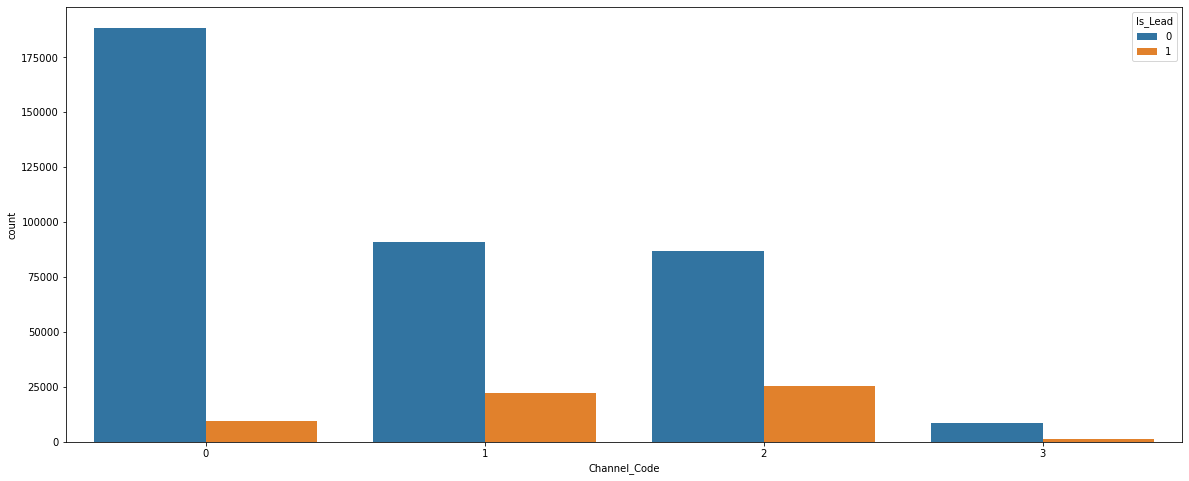

In [455]:
plt.figure(figsize=(20,8))
sns.countplot(x='Channel_Code',data=df,hue='Is_Lead')

<Axes: xlabel='Occupation', ylabel='count'>

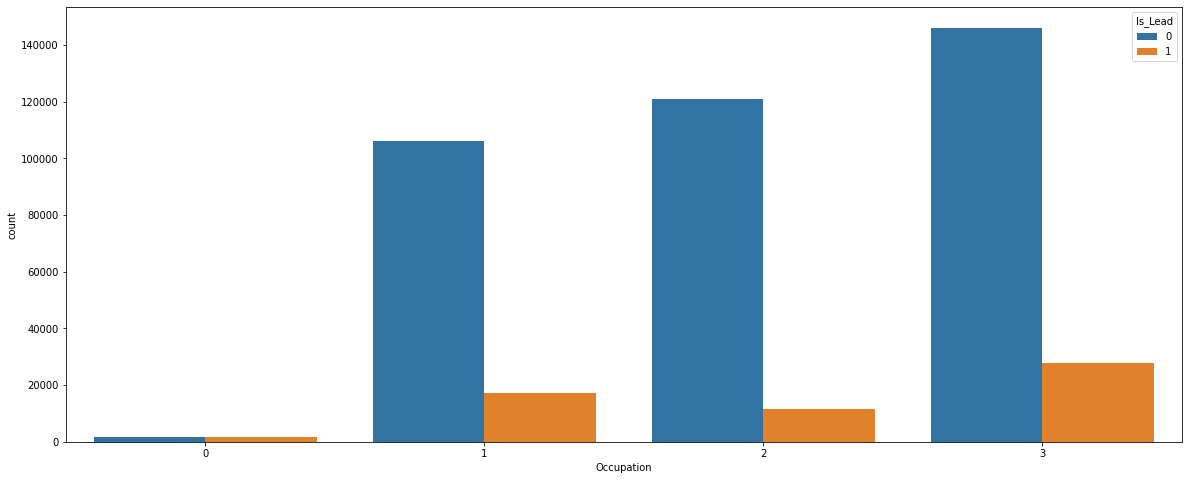

In [456]:
plt.figure(figsize=(20,8))
sns.countplot(x='Occupation',data=df,hue='Is_Lead')

<Axes: xlabel='Age', ylabel='count'>

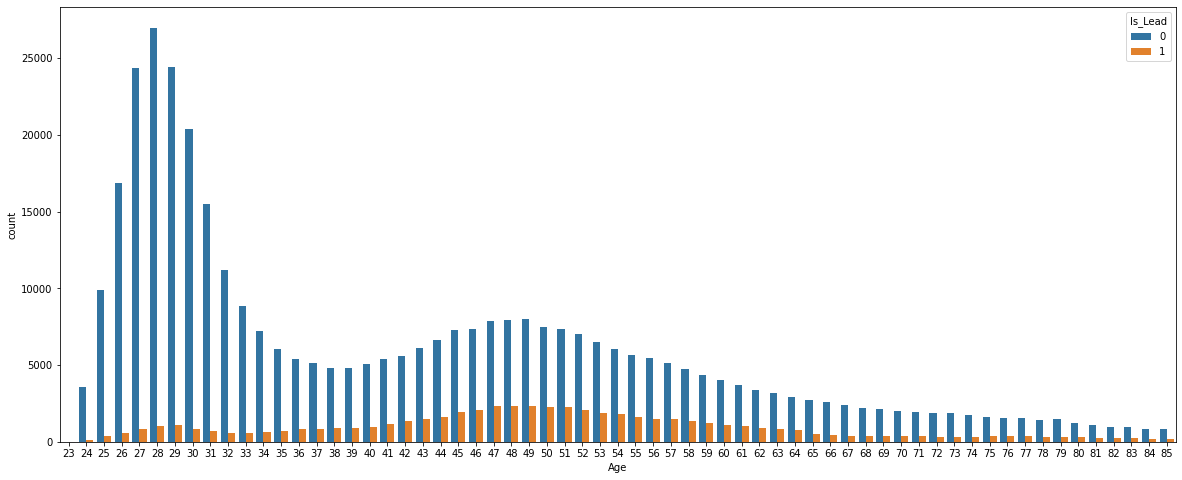

In [457]:
plt.figure(figsize=(20,8))
sns.countplot(x='Age',data=df,hue='Is_Lead')

In [458]:
from sklearn.preprocessing import LabelEncoder
lb_en=LabelEncoder()

In [459]:
df['Gender']=lb_en.fit_transform(df['Gender'])
df['Is_Active']=lb_en.fit_transform(df['Is_Active'])
df['Channel_Code']=lb_en.fit_transform(df['Channel_Code'])
df['Region_Code']=lb_en.fit_transform(df['Region_Code'])
df['Occupation']=lb_en.fit_transform(df['Occupation'])

# Credit_Product have nan Values

In [460]:
df['Credit_Product'].value_counts()

Credit_Product
0    311766
1    121396
Name: count, dtype: int64

In [461]:
df['Credit_Product'].isna().sum()

0

In [462]:
df.Credit_Product.replace(np.nan,'No',regex = True,inplace=True)

In [463]:
df['Credit_Product'].isna().sum()

0

In [464]:
df['Credit_Product']=lb_en.fit_transform(df['Credit_Product'])

In [465]:
df

,Gender,Age,Region_Code,Occupation,Channel_Code,Vintage,Credit_Product,Avg_Account_Balance,Is_Active,Is_Lead
0,0,73,18,1,2,43,0,1045696,0,0
1,0,30,27,2,0,32,0,581988,0,0
2,0,56,18,3,2,26,0,1484315,1,0
3,1,34,20,2,0,19,0,470454,0,0
4,0,30,32,2,0,33,0,886787,0,0
...,...,...,...,...,...,...,...,...,...,...
433157,1,51,34,3,2,109,0,1925586,0,0
433158,1,27,18,2,0,15,0,862952,1,0
433159,0,26,31,2,0,13,0,670659,0,0
433160,0,28,23,2,0,31,0,407504,0,0


In [466]:
# independent and dependent datasets

In [467]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [468]:
print("Shape of Independent features :",X.shape)
print("Shape of Dependent features :",y.shape)

Shape of Independent features : (433162, 9)
Shape of Dependent features : (433162,)


In [469]:
df['Is_Lead'].value_counts()

Is_Lead
0    374874
1     58288
Name: count, dtype: int64

In [470]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=40)

In [471]:
#sacling the dataset
from sklearn.preprocessing import StandardScaler
Scaler =StandardScaler()
X_Scale_train=Scaler.fit_transform(X_train)
X_Scale_test=Scaler.fit_transform(X_test)

# Logistic Regression

In [472]:
from sklearn.linear_model import LogisticRegression

In [473]:
logisticRegr = LogisticRegression()

In [474]:
logisticRegr.fit(X_train, y_train)
y_pred = logisticRegr.predict(X_test)

In [475]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [476]:
y_test

80166     0
121710    0
285180    0
3965      0
4641      0
         ..
430506    0
309454    0
160671    1
174587    0
360096    0
Name: Is_Lead, Length: 173265, dtype: int64

In [477]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

C:\Users\Gavin Bedi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Gavin Bedi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.86      1.00      0.93    149820
           1       0.00      0.00      0.00     23445

    accuracy                           0.86    173265
   macro avg       0.43      0.50      0.46    173265
weighted avg       0.75      0.86      0.80    173265

[[149820      0]
 [ 23445      0]]


C:\Users\Gavin Bedi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Random Forest

In [478]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=20,random_state=0)
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)


In [479]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.93    149820
           1       0.69      0.20      0.31     23445

    accuracy                           0.88    173265
   macro avg       0.79      0.59      0.62    173265
weighted avg       0.86      0.88      0.85    173265

[[147780   2040]
 [ 18858   4587]]


# KNN Algorithm

In [480]:
from sklearn.neighbors import KNeighborsClassifier

In [481]:
classifier_knn=KNeighborsClassifier(n_neighbors=5)
classifier_knn.fit(X_train,y_train)
y_pred=classifier_knn.predict(X_test)

In [482]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92    149820
           1       0.29      0.06      0.10     23445

    accuracy                           0.85    173265
   macro avg       0.58      0.52      0.51    173265
weighted avg       0.79      0.85      0.81    173265

[[146408   3412]
 [ 22063   1382]]


# Prediction probabilities

In [483]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score




In [484]:
r_probs=[0 for _ in range(len(y_test))]
classifier_probs=classifier.predict_proba(X_test)
classifier_knn_probs=classifier_knn.predict_proba(X_test)
logisticRegr_probs=logisticRegr.predict_proba(X_test)

In [485]:
classifier_probs=classifier_probs[:,1]
classifier_knn_probs=classifier_knn_probs[:,1]
logisticRegr_probs=logisticRegr_probs[:,1]

In [486]:
classifier_auc=roc_auc_score(y_test,classifier_probs)
classifier_knn_auc=roc_auc_score(y_test,classifier_knn_probs)
logisticRegr_auc=roc_auc_score(y_test,logisticRegr_probs)



In [487]:
print('Random forest:AUCROC=% 0.3f '%(classifier_auc))
print('KNN ALGO:AUCROC=% 0.3f '%(classifier_knn_auc))
print('Logistic Regression:AUCROC=% 0.3f '%(logisticRegr_auc))

Random forest:AUCROC= 0.814 
KNN ALGO:AUCROC= 0.588 
Logistic Regression:AUCROC= 0.447 


In [488]:
# Predicting Test  Set Values

In [489]:
classifier_fpr,classifier_tpr, threshold =roc_curve(y_test,classifier_probs)
classifier_knn_fpr,classifier_knn_tpr, threshold=roc_curve(y_test,classifier_knn_probs)
logisticRegr_fpr,logisticRegr_tpr, threshold =roc_curve(y_test,logisticRegr_probs)

In [490]:
def plot_roc_curve(classifier_fpr,classifier_tpr):
  plt.plot(classifier_fpr,classifier_tpr,marker='.',label='Random Forest(AUCROC=% 0.3f)' %classifier_auc)
  plt.plot(classifier_knn_fpr,classifier_knn_tpr,marker='.',label='KNN algo(AUCROC=% 0.3f)' %classifier_knn_auc)
  plt.plot(logisticRegr_fpr,logisticRegr_tpr,marker='.',label='Logistic Regression(AUCROC=% 0.3f)' %logisticRegr_auc)
  plt.xlabel('False Positive Raclassifier_knn_fpr,classifier_knn_tpr, threshold=roc_curve(y_test,classifier_knn_probs)te')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend()
  plt.show()

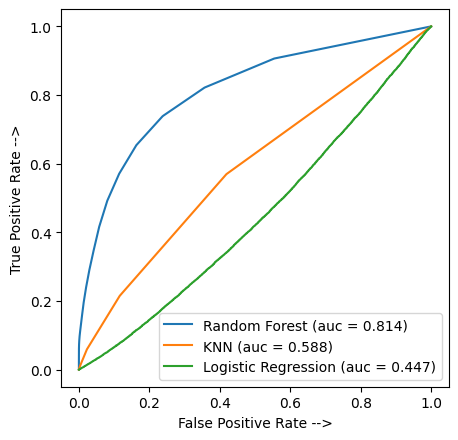

In [491]:

classifier_fpr,classifier_tpr, threshold =roc_curve(y_test,classifier_probs)
auc_classifier= auc(classifier_fpr, classifier_tpr)

classifier_knn_fpr,classifier_knn_tpr, threshold=roc_curve(y_test,classifier_knn_probs)
auc_classifier_knn= auc(classifier_knn_fpr, classifier_knn_tpr)


logisticRegr_fpr,logisticRegr_tpr, threshold =roc_curve(y_test,logisticRegr_probs)
auc_logisticRegr = auc(logisticRegr_fpr, logisticRegr_tpr)



plt.figure(figsize=(5, 5), dpi=100)
plt.plot(classifier_fpr, classifier_tpr, linestyle='-', label='Random Forest (auc = %0.3f)' % auc_classifier)
plt.plot(classifier_knn_fpr, classifier_knn_tpr, linestyle='-', label='KNN (auc = %0.3f)' % auc_classifier_knn)
plt.plot(logisticRegr_fpr, logisticRegr_tpr, linestyle='-', label='Logistic Regression (auc = %0.3f)' % auc_logisticRegr)


plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')

plt.legend()

plt.show()

# Case 2

In [492]:
X1=df.iloc[:,:-1]
y1=df.iloc[:,-1]

In [493]:
from sklearn.model_selection import train_test_split
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,test_size=0.6,random_state=40)

In [494]:
from sklearn.preprocessing import StandardScaler
Scaler =StandardScaler()
X_Scale_train=Scaler.fit_transform(X1_train)
X_Scale_test=Scaler.fit_transform(X1_test)

In [495]:
from sklearn.ensemble import RandomForestClassifier
classifier1=RandomForestClassifier(n_estimators=20,random_state=0)
classifier1.fit(X1_train,y1_train)
y1_pred=classifier1.predict(X1_test)

In [496]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y1_test,y1_pred))
print(confusion_matrix(y1_test,y1_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93    224761
           1       0.62      0.18      0.28     35137

    accuracy                           0.87    259898
   macro avg       0.75      0.58      0.60    259898
weighted avg       0.85      0.87      0.84    259898

[[220877   3884]
 [ 28908   6229]]


In [497]:
predictionsCat=classifier.predict(X1_test)


LABELS INFO:

 prob_min         : Minimum probability in a particular decile
 prob_max         : Minimum probability in a particular decile
 prob_avg         : Average probability in a particular decile
 cnt_events       : Count of events in a particular decile
 cnt_resp         : Count of responders in a particular decile
 cnt_non_resp     : Count of non-responders in a particular decile
 cnt_resp_rndm    : Count of responders if events assigned randomly in a particular decile
 cnt_resp_wiz     : Count of best possible responders in a particular decile
 resp_rate        : Response Rate in a particular decile [(cnt_resp/cnt_cust)*100]
 cum_events       : Cumulative sum of events decile-wise 
 cum_resp         : Cumulative sum of responders decile-wise 
 cum_resp_wiz     : Cumulative sum of best possible responders decile-wise 
 cum_non_resp     : Cumulative sum of non-responders decile-wise 
 cum_events_pct   : Cumulative sum of percentages of events decile-wise 
 cum_resp_pct     : Cu

,decile,prob_min,prob_max,prob_avg,cnt_cust,cnt_resp,cnt_non_resp,cnt_resp_rndm,cnt_resp_wiz,resp_rate,cum_cust,cum_resp,cum_resp_wiz,cum_non_resp,cum_cust_pct,cum_resp_pct,cum_resp_pct_wiz,cum_non_resp_pct,KS,lift
0,1,0.40,1.00,0.651,25990.0,19740.0,6250.0,3513.7,25990,75.952,25990.0,19740.0,25990,6250.0,10.0,56.180,73.968,2.781,53.399,5.618
1,2,0.20,0.40,0.261,25990.0,6891.0,19099.0,3513.7,9147,26.514,51980.0,26631.0,35137,25349.0,20.0,75.792,100.000,11.278,64.514,3.790
2,3,0.10,0.20,0.138,25990.0,2998.0,22992.0,3513.7,0,11.535,77970.0,29629.0,35137,48341.0,30.0,84.324,100.000,21.508,62.816,2.811
3,4,0.05,0.10,0.084,25990.0,1720.0,24270.0,3513.7,0,6.618,103960.0,31349.0,35137,72611.0,40.0,89.219,100.000,32.306,56.913,2.230
4,5,0.05,0.05,0.050,25989.0,1055.0,24934.0,3513.7,0,4.059,129949.0,32404.0,35137,97545.0,50.0,92.222,100.000,43.399,48.823,1.844
5,6,0.00,0.05,0.024,25990.0,537.0,25453.0,3513.7,0,2.066,155939.0,32941.0,35137,122998.0,60.0,93.750,100.000,54.724,39.026,1.562
6,7,0.00,0.00,0.000,25990.0,0.0,25990.0,3513.7,0,0.000,181929.0,32941.0,35137,148988.0,70.0,93.750,100.000,66.287,27.463,1.339
7,8,0.00,0.00,0.000,25990.0,734.0,25256.0,3513.7,0,2.824,207919.0,33675.0,35137,174244.0,80.0,95.839,100.000,77.524,18.315,1.198
8,9,0.00,0.00,0.000,25990.0,707.0,25283.0,3513.7,0,2.720,233909.0,34382.0,35137,199527.0,90.0,97.851,100.000,88.773,9.078,1.087
9,10,0.00,0.00,0.000,25989.0,755.0,25234.0,3513.7,0,2.905,259898.0,35137.0,35137,224761.0,100.0,100.000,100.000,100.000,0.000,1.000


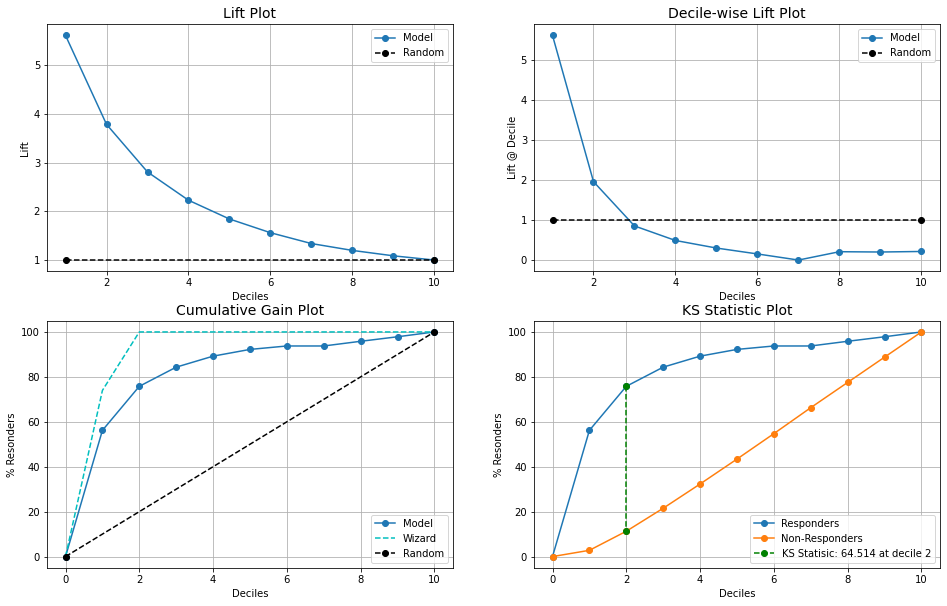

In [498]:
import kds
tabc1=kds.metrics.report(y1_test,classifier.predict_proba(X1_test)[:,1])
display(tabc1)

In [499]:
predictionsCatPLB=classifier.predict(X1_test)


In [500]:
predprobaBase=classifier.predict_proba(X1_test)


In [501]:
predprobaBase

array([[0.85, 0.15],
       [0.9 , 0.1 ],
       [0.35, 0.65],
       ...,
       [1.  , 0.  ],
       [0.9 , 0.1 ],
       [1.  , 0.  ]])

In [502]:
predictionsCatPLB

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [504]:
BaseProb=pd.DataFrame(predprobaBase)

In [505]:
BaseProb.rename(columns={1:'Pred_Probs'},inplace=True)


In [418]:
BaseProb.rename(columns={0:'Pred_ND'},inplace=True)

In [420]:
BaseProb.head(5)

,Pred_ND,Pred_Probs
0,0.85,0.15
1,0.90,0.10
2,0.35,0.65
3,1.00,0.00
4,0.95,0.05


In [ ]:
plt.scatter()  